# Defining wave and wind conditions
In this example, wind and wave definitions are described, and some useful visualization techniques are given.

In [1]:
from wawi import wave, wind
from wawi.model import Model, Aero, Hydro, Seastate, Windstate, AeroSection
from wawi.plot import plot_S2d, plot_dir_and_crests

import numpy as np
import matplotlib.pyplot as plt

## Sea state definition and plots
First, we define a set of sea state parameters and construct a `Seastate` object. The wave field definition is based on the assumption that the two-dimensional wave spectral density can be decomposed into a directional distribution and a one-dimensional wave spectral density, i.e.,  $S_\eta(\omega,\theta) = D(\theta) S(\omega)$. The two factors are defined using these well-known formulations:

* $S(\omega)$: JONSWAP spectrum  (see [Hasselmann et al., 1973](https://pure.mpg.de/pubman/faces/ViewItemOverviewPage.jsp?itemId=item_3262854) and [Kvåle et al., 2024](https://linkinghub.elsevier.com/retrieve/pii/S0141118723003437))
* $D(\theta)$: cos-2s directional distribution (see Longuet-Higgins et al., 1963 and [Kvåle et al., 2015](http://linkinghub.elsevier.com/retrieve/pii/S004579491500334X))

Currents are defined by a homogeneous current speed `U` and corresponding direction `thetaU`. 

It is noted that you can easily assign custom functions of the `S` and `D` of the seastate (or customly on all pontoons for full control) instead of relying on the built in JONSWAP and cos-2s definitions.

In [2]:
# JONSWAP parameters
Hs = 2.1
Tp = 8.3
gamma = 4

# Cos-2s directional distribution
s = 10
theta0 = 75.0

# Current specification
thetaU = 75.0
U = 1.0

seastate = Seastate(Tp, Hs, gamma, theta0, thetaU=thetaU, s=s)

To get an overview of the wave field appearance, the crests of a long-crested sea state with the given peak period and direction (assuming homogeneous $T_p$ and $\theta_0$) can be plotted using the `plot_dir_and_crests` function. The function assumes no current is present. The code cell below plots the crests for these two cases:

* No current (blue)
* Current aligned with the wave direction as implied by `U` and `thetaU` (red)
* Current opposing wave direction (U=-1.0) (green)

The figure shows that the wavelengths are increased as a following current is applied. If the currents are reversed

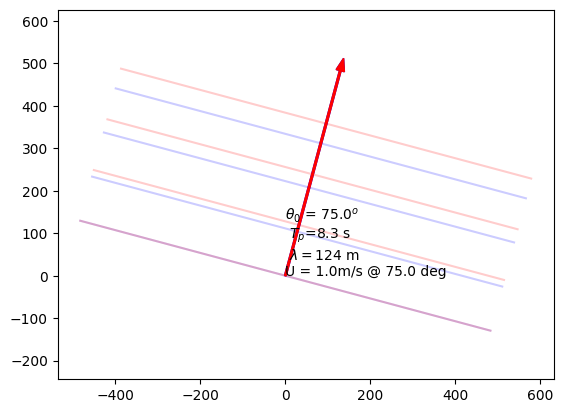

In [3]:
ax = plot_dir_and_crests(theta0, Tp, arrow_length=500, n_repeats=4, add_text=False, 
                         arrow_options=dict(width=4, head_width=20, edgecolor='blue', facecolor='blue'), 
                         crest_options=dict(color='blue'))

plot_dir_and_crests(theta0, Tp, U=U, thetaU=thetaU, arrow_length=500, n_repeats=4, 
                    arrow_options=dict(width=4, head_width=20, edgecolor='red', facecolor='red'), 
                    crest_options=dict(color='red'),ax=ax);

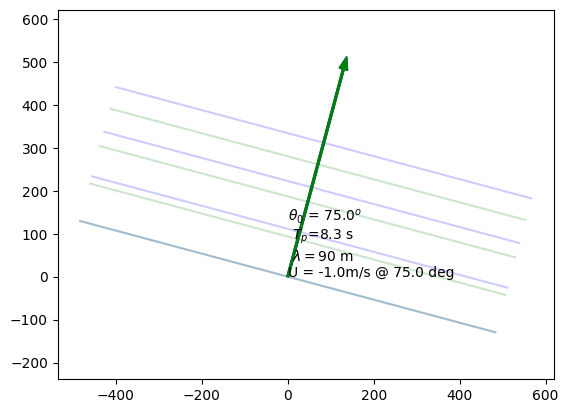

In [4]:
ax = plot_dir_and_crests(theta0, Tp, arrow_length=500, n_repeats=4, add_text=False, 
                         arrow_options=dict(width=4, head_width=20, edgecolor='blue', facecolor='blue'), 
                         crest_options=dict(color='blue'))

plot_dir_and_crests(theta0, Tp, U=-U, thetaU=thetaU, arrow_length=500, n_repeats=4, 
                    arrow_options=dict(width=4, head_width=20, edgecolor='green', facecolor='green'), 
                    crest_options=dict(color='green'),ax=ax);

The two-dimensional wave elevation spectral density can be established by the product of the directional spreading and the one-dimensional wave spectral density: $S_\eta(\omega,\theta) = D(\theta) S(\omega)$

The 2D spectral density can be plotted using the `plot_S2d` function in the `wave` module of WAWI. First, we get the `S` and `D` functions from the `Seastate` object. These are in general defined as functions of x and y; as our example is inohomogeneous, we extract the function at position (0,0).

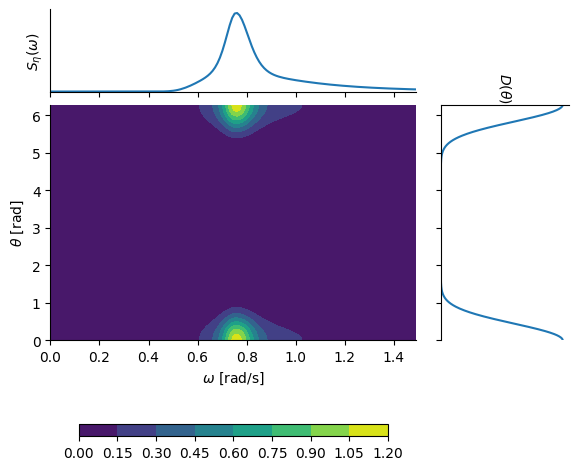

In [5]:
S = seastate.S(0,0) # using (x,y) = (0,0)
D = seastate.D(0,0) # using (x,y) = (0,0)
omega = np.arange(0.001, 1.5, 0.01)
theta = np.arange(0,2*np.pi, 0.01)

Snum = S(omega)
Dnum = D(theta)

plot_S2d(Snum, omega, theta, D=Dnum);

As seen above, the directional distribution peaks at $\theta = 0$. This is because the default option of the seastate is `centered_dirdist = True`. This implies that the directional distribution must be shifted by the defined $\theta_0$ of the sea state; this is done automatically in the analysis, and it does therefore not affect the results. For plotting, it might be more illustrative to plot the result in a global CSYS, with an directional distribution represented by absolute angular values. To do this, the setting `centered_dirdist` is simply adjusted, and the plotting repeated:

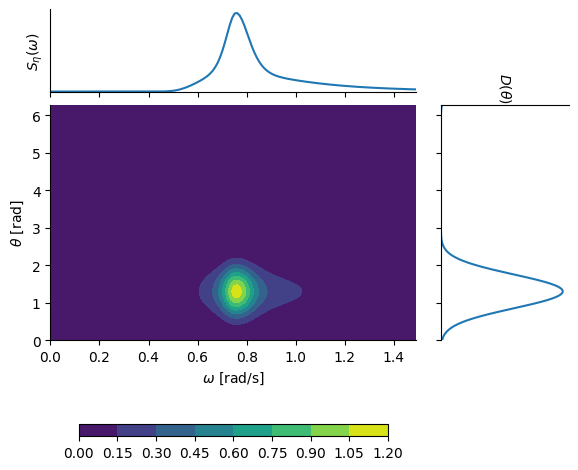

In [6]:
seastate.centered_dirdist = False
S = seastate.S(0,0) # using (x,y) = (0,0)
D = seastate.D(0,0) # using (x,y) = (0,0)
omega = np.arange(0.001, 1.5, 0.01)
theta = np.arange(0,2*np.pi, 0.01)

Snum = S(omega)
Dnum = D(theta)

ax = plot_S2d(Snum, omega, theta, D=Dnum);

## Wind state specification
The wind field is defined by single-point turbulence wind spectra (for all turbulence components $u$, $v$ and $w$) and coherence definitions.

By default, wind spectra can be defined using these two definitions:

* Kaimal spectrum defined by length scale parameters ($L^x_u$, $L^x_v$, $L^x_w$), spectral shape parameters ($A_u$, $A_v$ and $A_w$) and turbulence intensities ($I_u$, $I_v$ and $I_w$); see [Kaimal et al., 1972](https://www.climatexchange.nl/projects/alteddy/papers/Kaimal-1972.pdf)
* von Karmán spectrum defined by only length scale parameters ($L^x_u$, $L^x_v$, $L^x_w$) and turbulence intensities ($I_u=\sigma_u/U$, $I_v=\sigma_v/U$ and $I_w=\sigma_w/U$); see [von Kármán, 1948](http://dx.doi.org/10.1073/pnas.34.11.530)

Furthermore, the coherence of the wind field is defined by the nine decay parameters $C_{ux}$, $C_{vx}$, $C_{wx}$, $C_{uy}$, $C_{vy}$, $C_{wy}$, $C_{uz}$ $C_{vz}$, $C_{wz}$; see e.g. [Simiu and Scanlan, 1996](https://library.wur.nl/WebQuery/titel/1606468) for details

Kaimal and von Karmán spectra can be defined by providing relevant parameters upon initiation of the `Windstate` object:

In [7]:
U0 = 20.0
direction = 90.0

# Kaimal spectrum definition
windstate_kaimal = Windstate(U0, direction, Iu=0.136, Iw=0.072, Au=6.8, Aw=9.4, Cuy=10.0, Cwy=6.5, Lux=115, Lwx=9.58, spectrum_type='kaimal')

# von Karmán spectrum definition
windstate_karman = Windstate(U0, direction, Iu=0.136, Iw=0.072, Cuy=10.0, Cwy=6.5, Lux=115, Lwx=9.58, spectrum_type='vonkarman')

To plot the corresponding sea states, we can use the definitions in the `wind` module of WAWI directly:

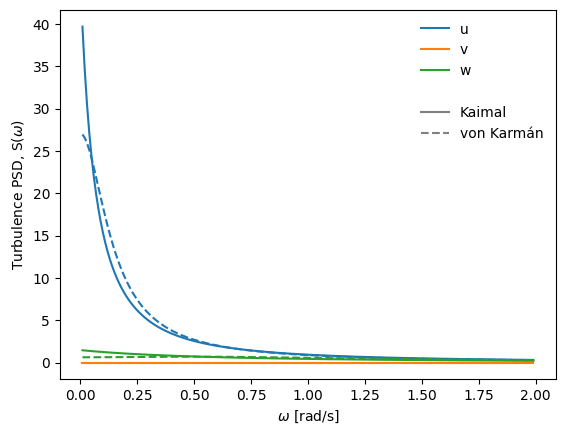

In [8]:
omega = np.arange(0.01, 2.0, 0.01)

S_kaimal = lambda om: wind.kaimal_auto(om, windstate_kaimal.Lx, windstate_kaimal.A, windstate_kaimal.sigma, windstate_kaimal.U0)
S_karman = lambda om: wind.von_karman_auto(om, windstate_kaimal.Lx, windstate_kaimal.sigma, windstate_kaimal.U0)

S_kaimal_num = np.vstack([S_kaimal(omi) for omi in omega])
S_karman_num = np.vstack([S_karman(omi) for omi in omega])

for ix, comp in enumerate(['u', 'v', 'w']):
    a = plt.plot(omega, S_kaimal_num[:,ix], label=f'{comp}')
    plt.plot(omega, S_karman_num[:,ix],  linestyle='--', color=a[0].get_color())

# Quasi-plots for legend entries
plt.plot(np.nan, np.nan, linestyle='-', color='white', label=' ')
plt.plot(np.nan, np.nan, linestyle='-', color='gray', label='Kaimal')
plt.plot(np.nan, np.nan, linestyle='--', color='gray', label='von Karmán')

# Axes labels
plt.xlabel('$\\omega$ [rad/s]')
plt.ylabel('Turbulence PSD, S($\\omega$)')

plt.legend(frameon=False);